In [7]:
! pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 48.0 MB/s  0:00:01 eta 0:00:010:00:01


In [1]:
import cv2

import numpy as np
import matplotlib.pyplot as plt
import torch

from PIL import Image

In [8]:
image = cv2.imread('img.jpg')

(np.float64(-0.5), np.float64(1949.5), np.float64(1962.5), np.float64(-0.5))

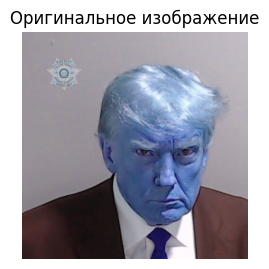

In [9]:
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Оригинальное изображение')
plt.axis('off')

(np.float64(-0.5), np.float64(1949.5), np.float64(1962.5), np.float64(-0.5))

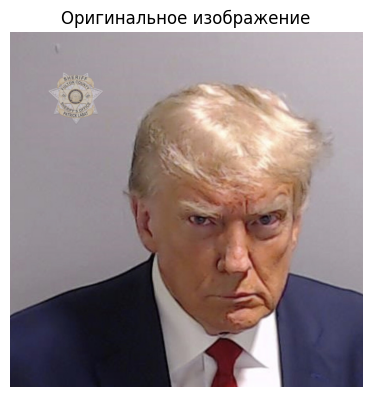

In [11]:
# поменяем местами каналы изображения - починим их порядок
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Оригинальное изображение')
plt.axis('off')

In [12]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [13]:
gray

array([[153, 150, 151, ..., 194, 193, 193],
       [153, 150, 151, ..., 194, 193, 193],
       [153, 150, 151, ..., 194, 193, 193],
       ...,
       [ 29,  30,  30, ...,  50,  50,  50],
       [ 29,  29,  30, ...,  50,  50,  50],
       [ 29,  28,  28, ...,  50,  50,  50]],
      shape=(1963, 1950), dtype=uint8)

(np.float64(-0.5), np.float64(1949.5), np.float64(1962.5), np.float64(-0.5))

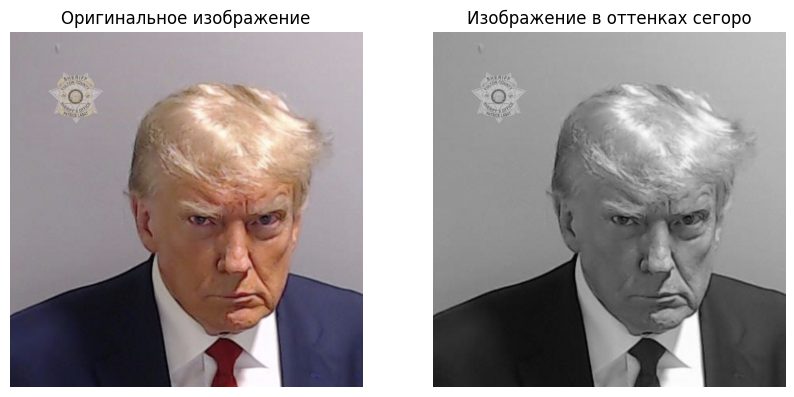

In [14]:
# поменяем местами каналы изображения - починим их порядок
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='grey')
plt.title('Изображение в оттенках сегоро')
plt.axis('off')

In [15]:
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

In [16]:
hsv_image

array([[[156,   8, 156],
        [156,   8, 153],
        [156,   8, 154],
        ...,
        [156,  13, 200],
        [156,  13, 199],
        [156,  13, 199]],

       [[156,   8, 156],
        [156,   8, 153],
        [156,   8, 154],
        ...,
        [156,  13, 200],
        [156,  13, 199],
        [156,  13, 199]],

       [[156,   8, 156],
        [156,   8, 153],
        [156,   8, 154],
        ...,
        [156,  13, 200],
        [156,  13, 199],
        [156,  13, 199]],

       ...,

       [[122,  95,  43],
        [122, 100,  46],
        [122, 100,  46],
        ...,
        [123, 115,  82],
        [123, 115,  82],
        [123, 115,  82]],

       [[122,  95,  43],
        [122, 102,  45],
        [122, 100,  46],
        ...,
        [123, 115,  82],
        [123, 115,  82],
        [123, 115,  82]],

       [[122,  95,  43],
        [122, 104,  44],
        [122, 104,  44],
        ...,
        [123, 115,  82],
        [123, 115,  82],
        [123, 115,  82]]

(np.float64(-0.5), np.float64(1949.5), np.float64(1962.5), np.float64(-0.5))

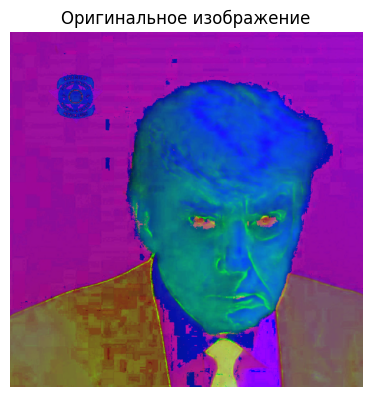

In [17]:
# поменяем местами каналы изображения - починим их порядок
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(hsv_image)
plt.title('Оригинальное изображение')
plt.axis('off')

(np.float64(-0.5), np.float64(1949.5), np.float64(1962.5), np.float64(-0.5))

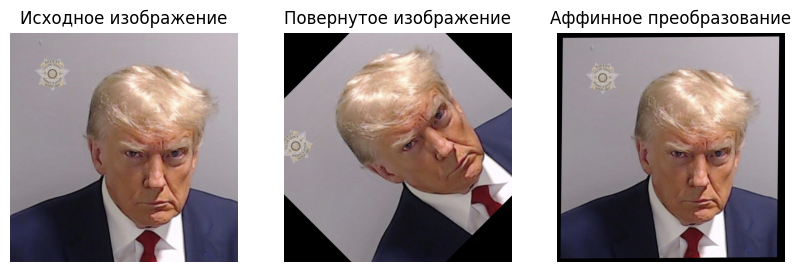

In [23]:
# Посмотрим на афинные(Линейные) преобразования изображения
height, width = image.shape[:2]

M = cv2.getRotationMatrix2D((width / 2, height / 2), 45, 1.0) # Матрица поворота
rotated = cv2.warpAffine(image, M, (width, height))

src_points = np.float32([[0, 0], [width - 1, 0], [0, height - 1]]) # Исходные точки dst_points = np. float32([[50, 50], [width - 50, 38], (30, height - 30]]) # Целевые точки
dst_points = np. float32([[50, 50], [width - 50, 38], [30, height - 30]])

affine_matrix = cv2.getAffineTransform(src_points, dst_points)
affine_transformed = cv2.warpAffine(image, affine_matrix, (width, height))

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(rotated,
cv2. COLOR_BGR2RGB))
plt. title('Повернутое изображение')
plt.axis('off')

plt.subplot (1, 3, 3)
plt.imshow(cv2.cvtColor(affine_transformed, cv2.COLOR_BGR2RGB) )
plt.title('Аффинное преобразование')
plt.axis('off')

In [24]:
affine_matrix

array([[ 9.49204720e-01, -1.01936799e-02,  5.00000000e+01],
       [-6.15700359e-03,  9.59734964e-01,  5.00000000e+01]])

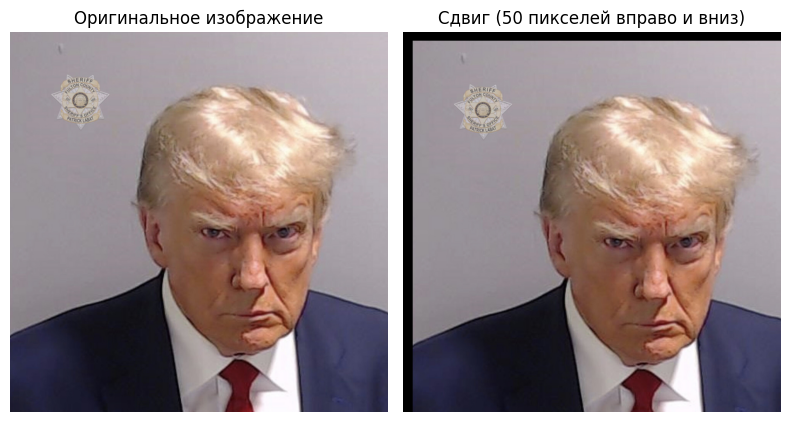

In [31]:
# получение размеров изображения
height, width = image.shape[:2]

# сдвиг (перемещение на 50 пикселей вправо и вниз)
translation_matrix = np. float32([[1, 0, 50], [0, 1, 50]])
translated_image = cv2.warpAffine(image, translation_matrix, (width, height))

plt.figure(figsize=(8, 6))
plt.subplot (1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Оригинальное изображение")
plt.axis('off')
plt.subplot (1, 2, 2)
plt.imshow(cv2.cvtColor(translated_image, cv2.COLOR_BGR2RGB))
plt.title('Сдвиг (50 пикселей вправо и вниз)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [35]:
gaussian = cv2.GaussianBlur(image, (5,5), 1.0)
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
laplacian = cv2.Laplacian(image, cv2.CV_64F, ksize=3)

(np.float64(-0.5), np.float64(1949.5), np.float64(1962.5), np.float64(-0.5))

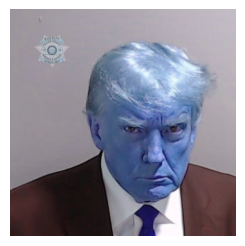

In [36]:
plt.subplot(1, 2, 1)
plt.imshow(gaussian)
plt.axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-377.0..361.0].


(np.float64(-0.5), np.float64(1949.5), np.float64(1962.5), np.float64(-0.5))

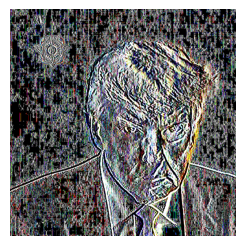

In [38]:
plt.subplot(1, 2, 1)
plt.imshow(sobel_x)
plt.axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-414.0..450.0].


(np.float64(-0.5), np.float64(1949.5), np.float64(1962.5), np.float64(-0.5))

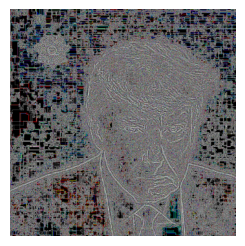

In [39]:
plt.subplot(1, 2, 1)
plt.imshow(laplacian)
plt.axis('off')

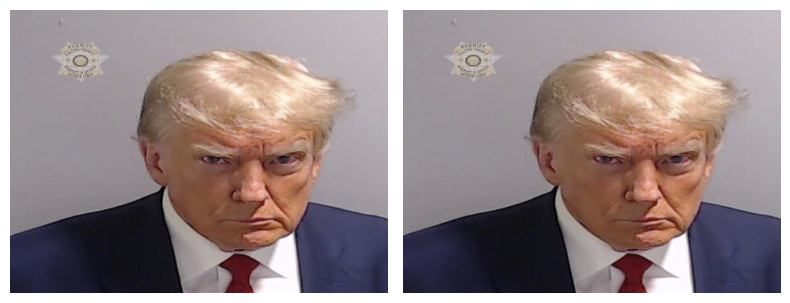

In [40]:
nn = cv2.resize(image, (800,600), interpolation=cv2. INTER_NEAREST)
bilin = cv2.resize(image, (800,600), interpolation=cv2. INTER_LINEAR)
plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(nn, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(bilin, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

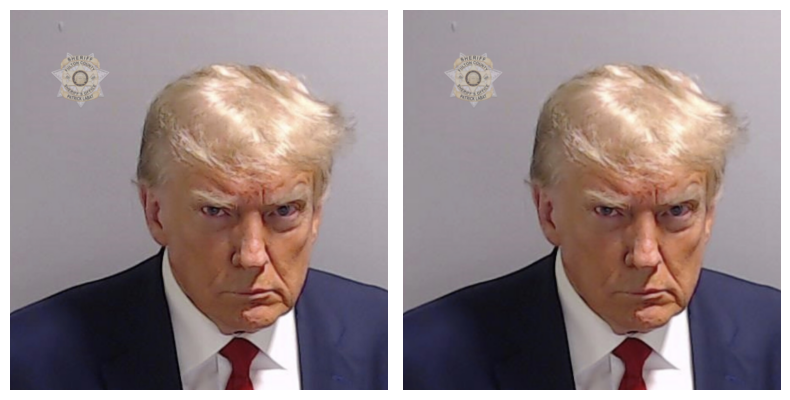

In [42]:
median = cv2.medianBlur(image, 5)
bilateral = cv2.bilateralFilter(image, 9, 75, 75)
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(median, cv2. COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()

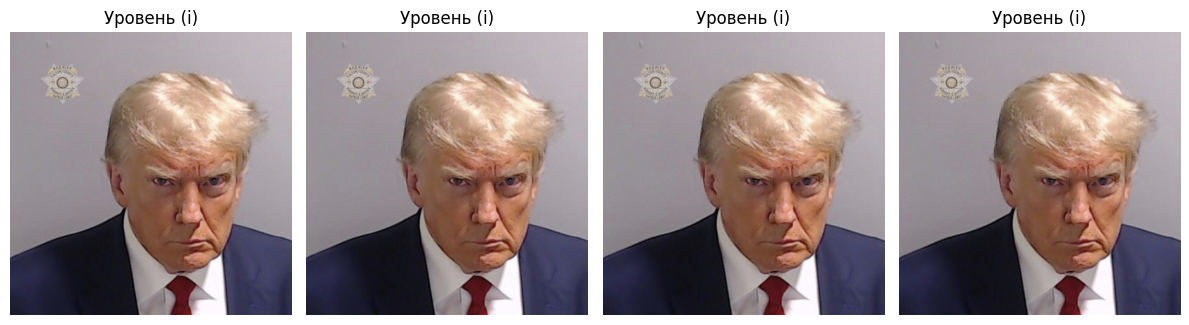

In [46]:
# создание гауссовой пирамиды
gpyr = [image]
for _ in range(3):
    img = cv2.pyrDown(gpyr[-1])
    gpyr.append(img)
plt.figure(figsize=(12, 6))

for i in range(len(gpyr)):
    plt.subplot(1, len(gpyr), i + 1)
    plt.imshow(cv2.cvtColor(gpyr[1], cv2.COLOR_BGR2RGB))
    plt.title(f'Уровень (i)')
    plt.axis('off')
    
plt.tight_layout()
plt.show()

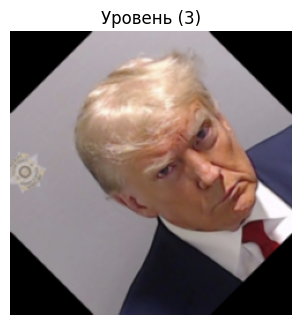

In [51]:
# параметры для аффинного преобразования
(h, w) = image.shape[:2]
center = (w // 2, h // 2)
angle = 45 # угол поворота
scale = 1.0 # масштаб

M = cv2.getRotationMatrix2D(center, angle, scale)

corrected = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR)

# применение билинейного фильтра для уменьшения шума
denoised = cv2.bilateralFilter(corrected, 9, 75, 75)

# гауссова пирамида
gpyr = [denoised]
for _ in range(3):
    denoised = cv2.pyrDown(denoised)
    gpyr.append(denoised)
plt.figure(figsize=(12, 6))

for i in range(len(gpyr)):
    plt.subplot(1, len(gpyr), 1 + 1)
    plt.imshow(cv2.cvtColor(gpyr[i], cv2.COLOR_BGR2RGB))
    plt.title(f'Уровень ({i})')
    plt.axis('off')

plt.tight_layout()
plt.show()

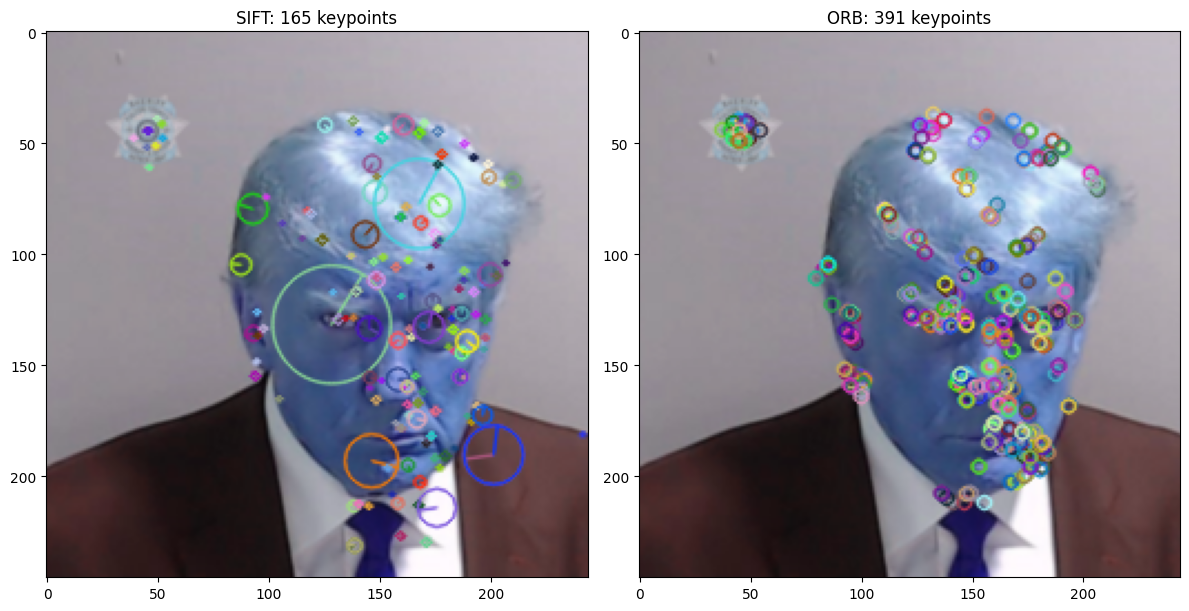

In [59]:
# инициализация детектора
sift = cv2.SIFT_create()
orb = cv2.ORB_create()

# Детекция ключевых точек и дескрипторов
kp_sift, des_sift = sift.detectAndCompute(img, None)
kp_orb, des_orb = orb.detectAndCompute(img, None)

# отрисовка ключевых точек
img_sift = cv2.drawKeypoints(img, kp_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_orb = cv2.drawKeypoints(img, kp_orb, None, flags=0)

plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.imshow(img_sift, cmap='gray')
plt.title(f'SIFT: {len(kp_sift)} keypoints')
plt.subplot(1, 2, 2)
plt.imshow(img_orb, cmap='gray')
plt.title(f'ORB: {len(kp_orb)} keypoints')
plt.tight_layout()
plt.show()